In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

# Agregamos la carpeta superior (la raíz del proyecto) al sistema de búsqueda
sys.path.append(os.path.abspath(".."))

from src.utils.cleaning_methods import *


## Carga de datos

In [57]:
# Declaración del Path y carga del csv en un dataframe
PATH = '../output/catalog_film.csv'
df_original = charge_path(PATH)
df = df_original.copy()
df.head()

,title,category,length,rating,language,total_inventory,total_rentals
0,academy dinosaur,documentary,86,PG,english,7,23
1,ace goldfinger,horror,48,G,english,3,7
2,adaptation holes,documentary,50,NC-17,english,4,12
3,affair prejudice,horror,117,G,english,7,23
4,african egg,family,130,G,english,3,12


## Exploración rápida del dataset

In [58]:
num_columnas, num_filas, num_duplicados, null_values, df_porcentaje_nulos_columna, df_describe_numeric, df_describe_categorical = first_visualizer(df)

In [59]:
show_head(df)

,title,category,length,rating,language,total_inventory,total_rentals
0,academy dinosaur,documentary,86,PG,english,7,23
1,ace goldfinger,horror,48,G,english,3,7
2,adaptation holes,documentary,50,NC-17,english,4,12
3,affair prejudice,horror,117,G,english,7,23
4,african egg,family,130,G,english,3,12
5,agent truman,foreign,169,PG,english,6,21
6,airplane sierra,comedy,62,PG-13,english,5,15
7,airport pollock,horror,54,R,english,4,18
8,alabama devil,horror,114,PG-13,english,5,12
9,aladdin calendar,sports,63,NC-17,english,7,23


In [60]:
print(f'El dataset tiene {num_filas} filas.')
print(f'El dataset tiene {num_columnas} columnas.')

El dataset tiene 958 filas.
El dataset tiene 7 columnas.


In [61]:
print(f'El dataset tiene {num_duplicados} duplicados.')

El dataset tiene 0 duplicados.


In [62]:
print(f'El dataset tiene {null_values} valores nulos.\n')
print('Valores nulos por columna:')
df_porcentaje_nulos_columna

El dataset tiene 0 valores nulos.

Valores nulos por columna:


(title              0.0
 category           0.0
 length             0.0
 rating             0.0
 language           0.0
 total_inventory    0.0
 total_rentals      0.0
 dtype: float64,
 2)

In [63]:
show_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            958 non-null    object
 1   category         958 non-null    object
 2   length           958 non-null    int64 
 3   rating           958 non-null    object
 4   language         958 non-null    object
 5   total_inventory  958 non-null    int64 
 6   total_rentals    958 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 52.5+ KB


In [64]:
df_describe_numeric

,length,total_inventory,total_rentals
count,958.000000,958.000000,958.000000
mean,115.490605,4.780793,16.747390
std,40.471844,1.814825,6.676185
min,46.000000,2.000000,4.000000
25%,80.250000,3.000000,11.000000
50%,114.000000,5.000000,16.000000
75%,150.000000,6.000000,22.000000
max,185.000000,8.000000,34.000000


In [65]:
df_describe_categorical

,title,category,rating,language
count,958,958,958,958
unique,958,16,5,1
top,academy dinosaur,sports,PG-13,english
freq,1,73,213,958


Al realizar esta exploración podemos ver que el dataset no presenta duplicados, valores nulos y los diferentes tipos de columnas y sus tipos. Al hacer un analisis podemos observar como la columna `languaje` es la misma en todos los registros, por lo que no aporta información y tendríamos que proceder a elimnarla en futuros pasos.

## Normalización

Unificamos todos los datos para que estén en el mismo formato, es decir todos en minúsuclas y en el caso de poseer un espacio, sustituirlo por `_`.

In [66]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

In [67]:
# Normalización a tipo fecha y string
df_cleandf_clean = normalize_date_columns(df)
df_clean = normalize_string_columns(df)

In [68]:
show_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            958 non-null    string
 1   category         958 non-null    string
 2   length           958 non-null    int64 
 3   rating           958 non-null    string
 4   language         958 non-null    string
 5   total_inventory  958 non-null    int64 
 6   total_rentals    958 non-null    int64 
dtypes: int64(3), string(4)
memory usage: 52.5 KB


## Borrado de comunas que no aportan valor

In [69]:
df = delete_columns(df, ['language'])

In [70]:
show_head(df, 5)

,title,category,length,rating,total_inventory,total_rentals
0,academy dinosaur,documentary,86,pg,7,23
1,ace goldfinger,horror,48,g,3,7
2,adaptation holes,documentary,50,nc17,4,12
3,affair prejudice,horror,117,g,7,23
4,african egg,family,130,g,3,12


In [71]:
show_info(df_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            958 non-null    string
 1   category         958 non-null    string
 2   length           958 non-null    int64 
 3   rating           958 non-null    string
 4   language         958 non-null    string
 5   total_inventory  958 non-null    int64 
 6   total_rentals    958 non-null    int64 
dtypes: int64(3), string(4)
memory usage: 52.5 KB


## Tratamiento de valores Nulos y Outliers

In [72]:
identify_nulls(df)

--------------------------------
En este caso no se encuentran valores nulos por lo que no se procede a eliminar filas.


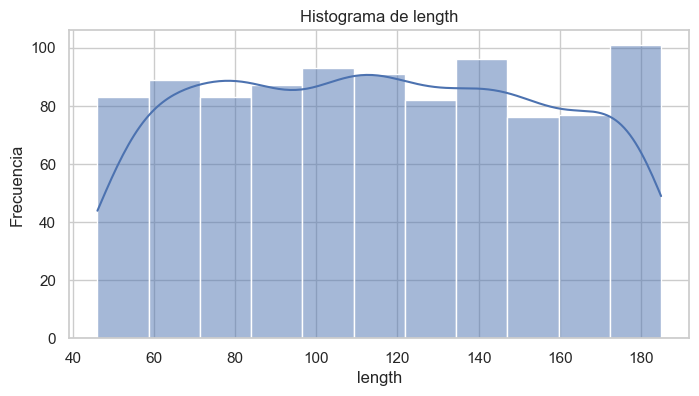

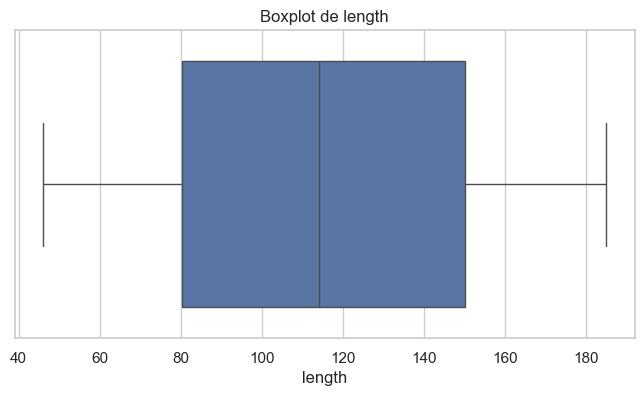

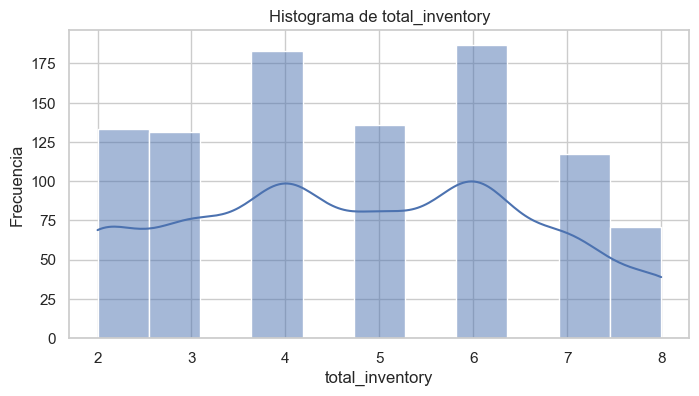

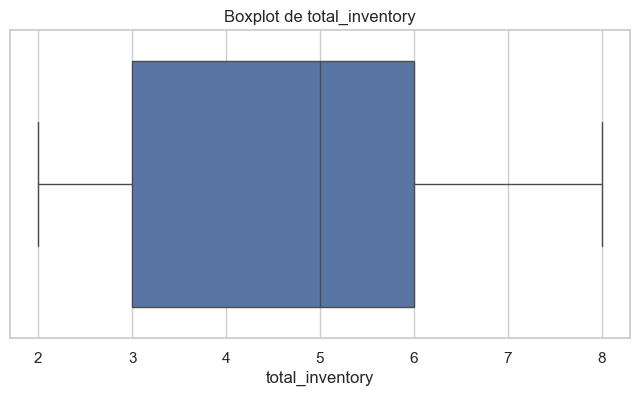

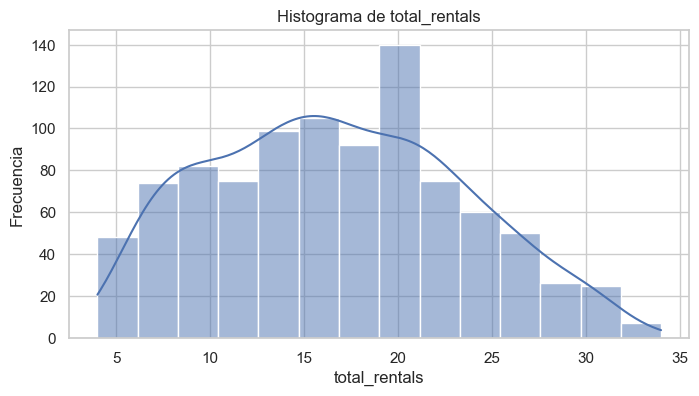

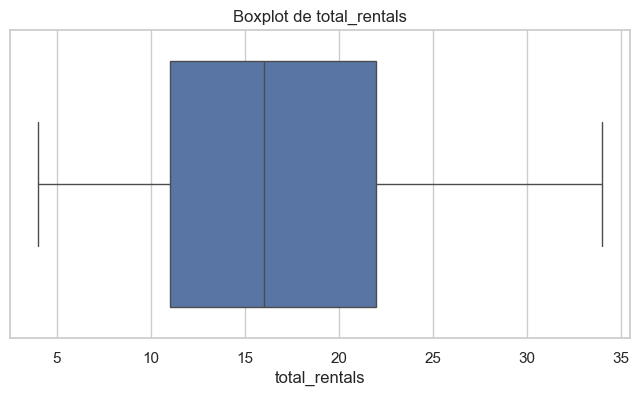

In [73]:
columns_numeric = df.select_dtypes("number").columns
columns_categorical = df.select_dtypes("object").columns

identify_outliers(df,columns_numeric,columns_categorical)

In [74]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            958 non-null    string
 1   category         958 non-null    string
 2   length           958 non-null    int64 
 3   rating           958 non-null    string
 4   total_inventory  958 non-null    int64 
 5   total_rentals    958 non-null    int64 
dtypes: int64(3), string(3)
memory usage: 45.0 KB


En este caso podemos observar tanto en el código como en la gráfica la ausencia de valores outliers

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_24607/18115750.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


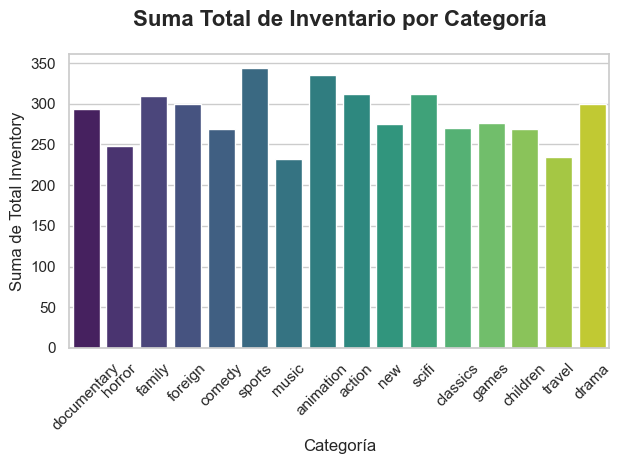

In [75]:
sns.barplot(
    data=df, 
    x='category', 
    y='total_inventory', 
    estimator=sum, 
    errorbar=None,
    palette='viridis'
)

plt.title('Suma Total de Inventario por Categoría', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Suma de Total Inventory', fontsize=12)

plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

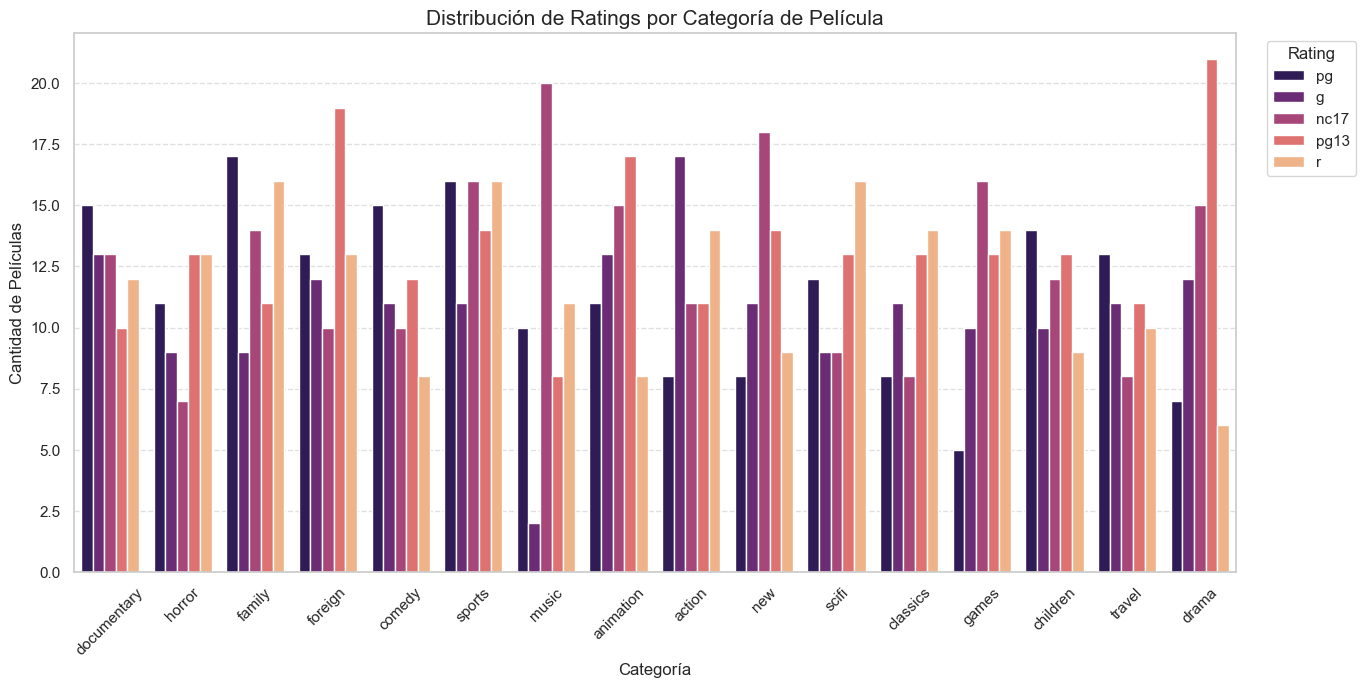

In [76]:
# Configuramos el tamaño de la figura 
plt.figure(figsize=(15, 7))

# Creamos el gráfico de barras
# x: Categoría, hue: Rating (colores por cada tipo de clasificación)
sns.countplot(data=df, x='category', hue='rating', palette='magma')

# Personalización de etiquetas
plt.title('Distribución de Ratings por Categoría de Película', fontsize=15)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Cantidad de Películas', fontsize=12)

# Rotamos los nombres de las categorías 45 grados para que sean legibles
plt.xticks(rotation=45)

# Movemos la leyenda fuera del gráfico para que no tape las barras
plt.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.6) # Una rejilla ligera para ayudar a leer los valores
plt.show()

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_24607/1657567041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='length', palette='Set3')


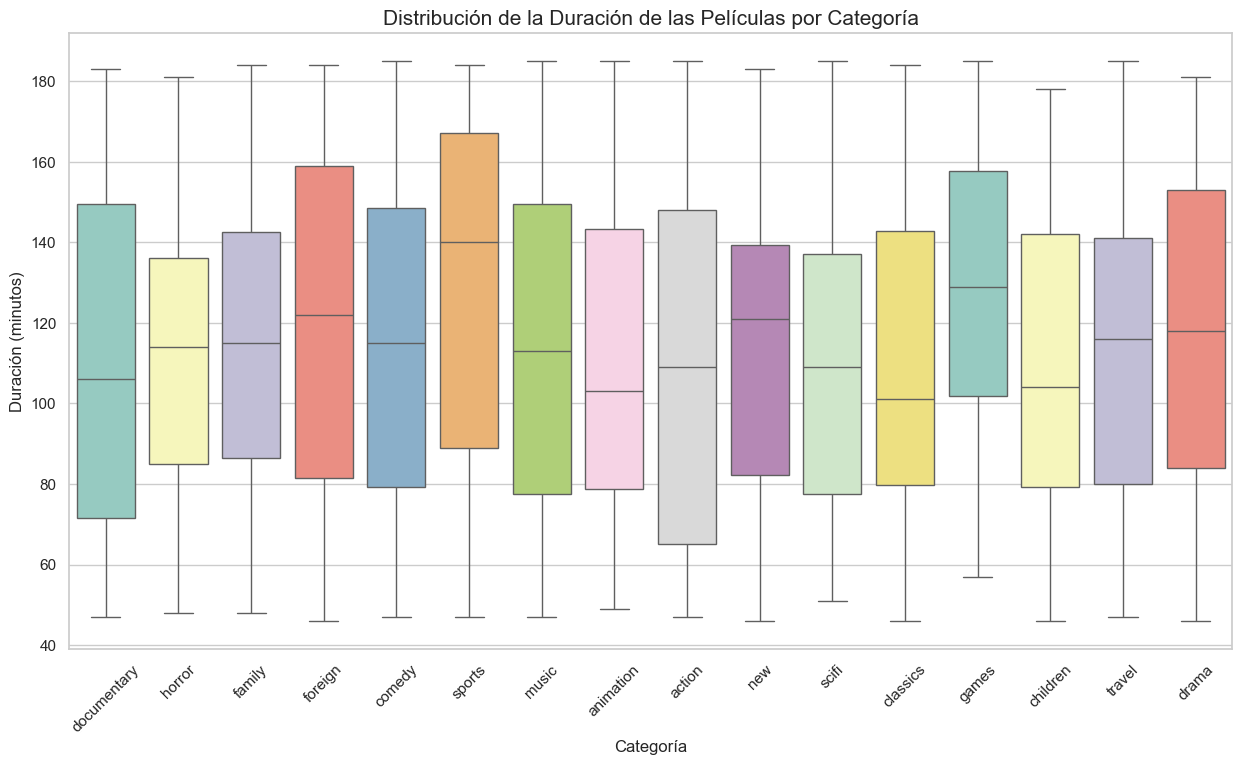

In [77]:
plt.figure(figsize=(15, 8))

# x: Categoría, y: Duración
sns.boxplot(data=df, x='category', y='length', palette='Set3')

plt.title('Distribución de la Duración de las Películas por Categoría', fontsize=15)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Duración (minutos)', fontsize=12)
plt.xticks(rotation=45)

plt.show()

## Exportación de datos procesados a CSV

In [ ]:
load_clean_data(df, '../output/catalog_film_clean.csv')